# China — EDA, TTC-модели, SHAP

**Что тут:** EDA → Stage-1 (Through-The-Cycle) → проверка H1 и H2 по Китаю.

* **H1.** Ансамбли (RF, XGBoost) выдают более высокий ROC-AUC, чем Logit, но у них больше **зазор train–test** (переобучение).
* **H2.** Сумма `|SHAP|` по блокам **Ликвидность + Инновации (НМА+R&D)** выше, чем по блоку **Леверидж**.

**Выборка:** 339 активных Wind-компаний + 11 реально-дефолтных (11 vs 3412 строк, дисбаланс ≈ 1:71). Выбросы по делистингу с экономически нерелевантными причинами (M&A, приватизация) уже удалены на этапе загрузки (`30_china_load_and_clean.ipynb`) — то есть здесь мы проверяем Hypotheses именно на *true economic distress*.

**Правила научрука:** без SMOTE, `class_weight='balanced'`, stratified split. Артефакты сохраняются в `reports/china/`.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

from xgboost import XGBClassifier
import shap

RNG = 42
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

PROCESSED = Path('../data/processed')
REPORTS = Path('../reports/china')
REPORTS.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    path = REPORTS / f'{name}.png'
    fig.savefig(path, dpi=160, bbox_inches='tight')
    print(f'  saved → {path}')

_report_lines = ['# China — Stage-1 (TTC) results\n']
def log(msg=''):
    print(msg)
    _report_lines.append(msg)

df = pd.read_csv(PROCESSED / 'cn_panel_cleaned.csv', encoding='utf-8-sig')
print('Shape:', df.shape)
print('Tickers per target:', df.groupby('target')['ticker'].nunique().to_dict())
df.head(3)

Shape: (3460, 20)
Tickers per target: {0: 339, 1: 11}


,ticker,company_name,year,total_revenue,ebit,ebitda,total_assets,total_liab,total_equity,current_assets,current_liab,cash,intangibles,cfo,interest_expense,rd_expense,net_profit,net_revenue,target,source_class
0,CCIHY.OO,CHINACACHE,2014,226.23,-2.86,0.0,282.92,146.47,136.45,141.33,141.22,61.43,0.0,45.82,0.0,19.02,0.0,0.0,1,default_delisted
1,CCIHY.OO,CHINACACHE,2015,208.46,-20.46,0.0,403.26,292.12,111.14,305.97,274.07,94.90,0.0,118.65,0.0,15.88,0.0,0.0,1,default_delisted
2,CCIHY.OO,CHINACACHE,2016,151.97,-70.09,0.0,256.14,276.68,-20.54,245.95,268.73,22.58,0.0,-26.98,0.0,14.99,0.0,0.0,1,default_delisted


## 1. Feature engineering

Мэппинг колонок `cn_panel_cleaned.csv` в ratios H2. В китайской выборке есть **R&D expense** — это отдельный канал «Innovation» сверх нематериальных активов, что важно для H2.

* **Liquidity:** `current_ratio`, `cash_to_assets`, `cash_to_cl`, `wc_to_assets`
* **Innovation:** `intangibles_to_assets`, `rd_to_revenue`
* **Leverage:** `debt_to_assets`, `debt_to_equity`, `lt_debt_to_assets`, `interest_coverage`
* **Profitability:** `roa`, `net_margin`, `operating_margin`, `cfo_to_assets`
* **Size:** `log_assets`, `log_revenue`

Винзоризация 1/99% — как в российской тетради. Пропуски заполняются медианой (после ffill/bfill внутри компании в loader-ноутбуке).

In [2]:
TARGET = 'target'
ID_COL = 'ticker'

A, CA, CASH, INT_A = 'total_assets', 'current_assets', 'cash', 'intangibles'
EQ, LIAB, ST_L = 'total_equity', 'total_liab', 'current_liab'
REV, EBIT, NI = 'total_revenue', 'ebit', 'net_profit'
INTEREST, CFO, RD = 'interest_expense', 'cfo', 'rd_expense'

def safe_div(a, b):
    b = b.replace(0, np.nan)
    return a / b

panel = df.copy()
lt_liab = (panel[LIAB] - panel[ST_L]).clip(lower=0)

panel['current_ratio']         = safe_div(panel[CA], panel[ST_L])
panel['cash_to_assets']        = safe_div(panel[CASH], panel[A])
panel['cash_to_cl']            = safe_div(panel[CASH], panel[ST_L])
panel['wc_to_assets']          = safe_div(panel[CA] - panel[ST_L], panel[A])

panel['intangibles_to_assets'] = safe_div(panel[INT_A], panel[A])
panel['rd_to_revenue']         = safe_div(panel[RD], panel[REV])

panel['debt_to_assets']        = safe_div(panel[LIAB], panel[A])
panel['debt_to_equity']        = safe_div(panel[LIAB], panel[EQ])
panel['lt_debt_to_assets']     = safe_div(lt_liab, panel[A])
panel['interest_coverage']     = safe_div(panel[EBIT], panel[INTEREST])

panel['roa']              = safe_div(panel[NI], panel[A])
panel['net_margin']       = safe_div(panel[NI], panel[REV])
panel['operating_margin'] = safe_div(panel[EBIT], panel[REV])
panel['cfo_to_assets']    = safe_div(panel[CFO], panel[A])

panel['log_assets']  = np.log1p(panel[A].clip(lower=0))
panel['log_revenue'] = np.log1p(panel[REV].clip(lower=0))

FEATURES = [
    'current_ratio', 'cash_to_assets', 'cash_to_cl', 'wc_to_assets',
    'intangibles_to_assets', 'rd_to_revenue',
    'debt_to_assets', 'debt_to_equity', 'lt_debt_to_assets', 'interest_coverage',
    'roa', 'net_margin', 'operating_margin', 'cfo_to_assets',
    'log_assets', 'log_revenue',
]
FEATURE_GROUPS = {
    'Liquidity':     ['current_ratio', 'cash_to_assets', 'cash_to_cl', 'wc_to_assets'],
    'Innovation':    ['intangibles_to_assets', 'rd_to_revenue'],
    'Leverage':      ['debt_to_assets', 'debt_to_equity', 'lt_debt_to_assets', 'interest_coverage'],
    'Profitability': ['roa', 'net_margin', 'operating_margin', 'cfo_to_assets'],
    'Size':          ['log_assets', 'log_revenue'],
}

panel[FEATURES] = panel[FEATURES].replace([np.inf, -np.inf], np.nan)
for c in FEATURES:
    lo, hi = panel[c].quantile([0.01, 0.99])
    panel[c] = panel[c].clip(lo, hi)
panel[FEATURES] = panel[FEATURES].fillna(panel[FEATURES].median(numeric_only=True))

panel[FEATURES + [TARGET]].describe().T.round(3).to_csv(REPORTS / 'cn_feature_stats.csv', encoding='utf-8-sig')
print(f'Фичи: {len(FEATURES)}  |  stats → reports/china/cn_feature_stats.csv')
panel[FEATURES].describe().T.round(3)

Фичи: 16  |  stats → reports/china/cn_feature_stats.csv


,count,mean,std,min,25%,50%,75%,max
current_ratio,3460.0,185.116,768.143,0.996,6.977,17.250,51.951,6296.658
cash_to_assets,3460.0,0.222,0.153,0.008,0.106,0.189,0.304,0.714
cash_to_cl,3460.0,54.583,227.428,0.052,1.428,3.897,15.229,1891.196
wc_to_assets,3460.0,0.661,0.217,0.007,0.526,0.691,0.835,0.982
intangibles_to_assets,3460.0,0.028,0.036,0.000,0.004,0.015,0.038,0.193
rd_to_revenue,3460.0,0.150,0.138,0.000,0.063,0.112,0.192,0.822
debt_to_assets,3460.0,0.354,0.192,0.049,0.204,0.326,0.477,0.941
debt_to_equity,3460.0,0.745,0.864,0.043,0.252,0.476,0.902,5.430
lt_debt_to_assets,3460.0,0.280,0.169,0.000,0.157,0.255,0.377,0.803
interest_coverage,3460.0,83.996,60.013,14.925,81.906,81.906,81.906,2258.010


## 2. EDA

### 2.1 Классовый дисбаланс

  saved → ..\reports\china\01_class_distribution.png


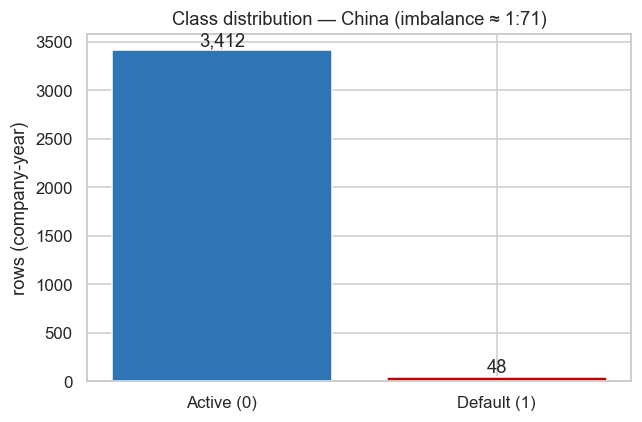


## Class balance
* Active (0): **3,412**
* Default (1): **48**
* Positive share: **1.387%**  (≈ 1:71)


In [3]:
vc = panel[TARGET].value_counts()
n_active  = int(vc.get(0, 0))
n_default = int(vc.get(1, 0))
ratio = n_default / (n_active + n_default)
counts = pd.Series({'Active (0)': n_active, 'Default (1)': n_default})

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values, color=['#2E75B6', '#C00000'])
ax.set_title(f'Class distribution — China (imbalance ≈ 1:{n_active//max(n_default,1)})')
ax.set_ylabel('rows (company-year)')
for b, v in zip(bars, counts.values):
    ax.text(b.get_x()+b.get_width()/2, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout()
save_fig(fig, '01_class_distribution'); plt.show()

log(f'\n## Class balance\n* Active (0): **{n_active:,}**')
log(f'* Default (1): **{n_default:,}**')
log(f'* Positive share: **{ratio*100:.3f}%**  (≈ 1:{n_active//max(n_default,1)})')

### 2.2 Violin plots — по классу

  saved → ..\reports\china\02_violin_by_class.png


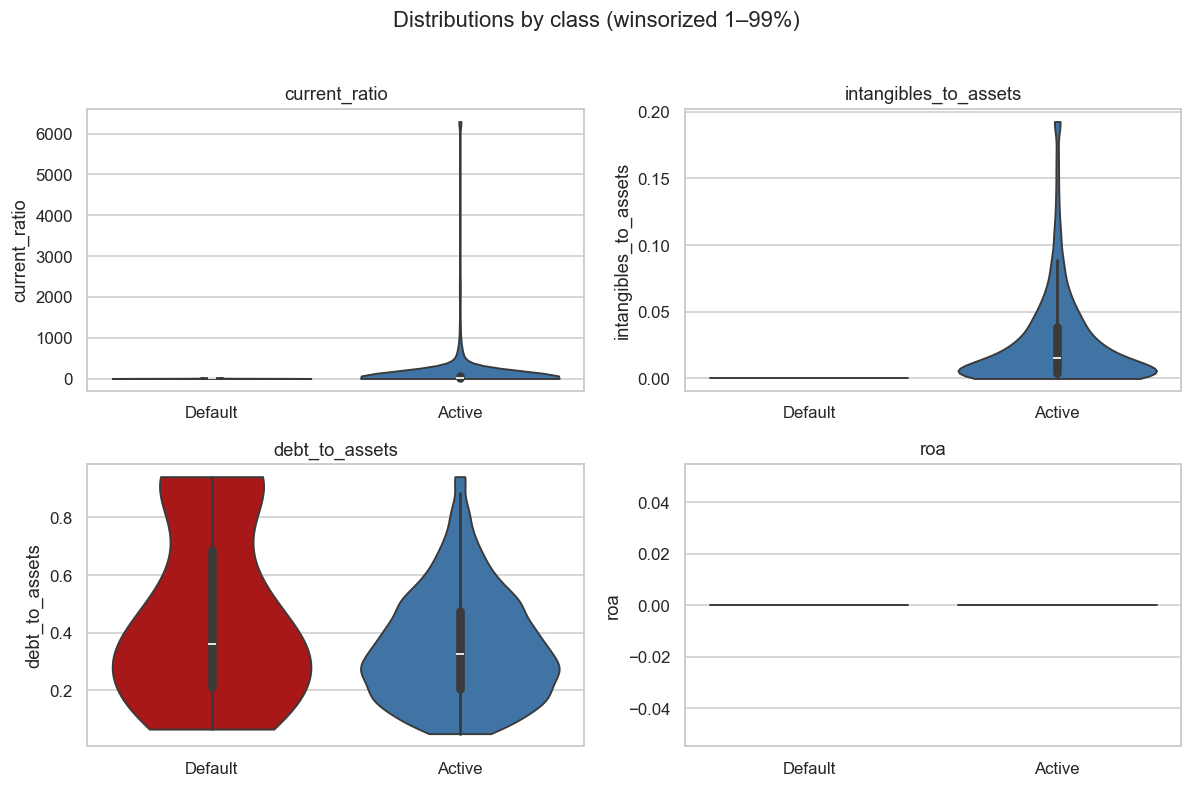

,current_ratio,intangibles_to_assets,debt_to_assets,roa
_lbl,,,,
Active,17.250,0.015,0.325,0.0
Default,2.121,0.000,0.361,0.0


In [4]:
panel['_lbl'] = panel[TARGET].map({0:'Active', 1:'Default'})
show = ['current_ratio', 'intangibles_to_assets', 'debt_to_assets', 'roa']

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.ravel(), show):
    sns.violinplot(data=panel, x='_lbl', y=col, ax=ax,
                   palette={'Active':'#2E75B6','Default':'#C00000'}, cut=0)
    ax.set_title(col); ax.set_xlabel('')
plt.suptitle('Distributions by class (winsorized 1–99%)', y=1.02)
plt.tight_layout()
save_fig(fig, '02_violin_by_class'); plt.show()

med = panel.groupby('_lbl')[show].median().round(3)
med.to_csv(REPORTS / 'cn_medians_by_class.csv', encoding='utf-8-sig')
med

### 2.3 Корреляционная матрица

  saved → ..\reports\china\03_correlation_heatmap.png


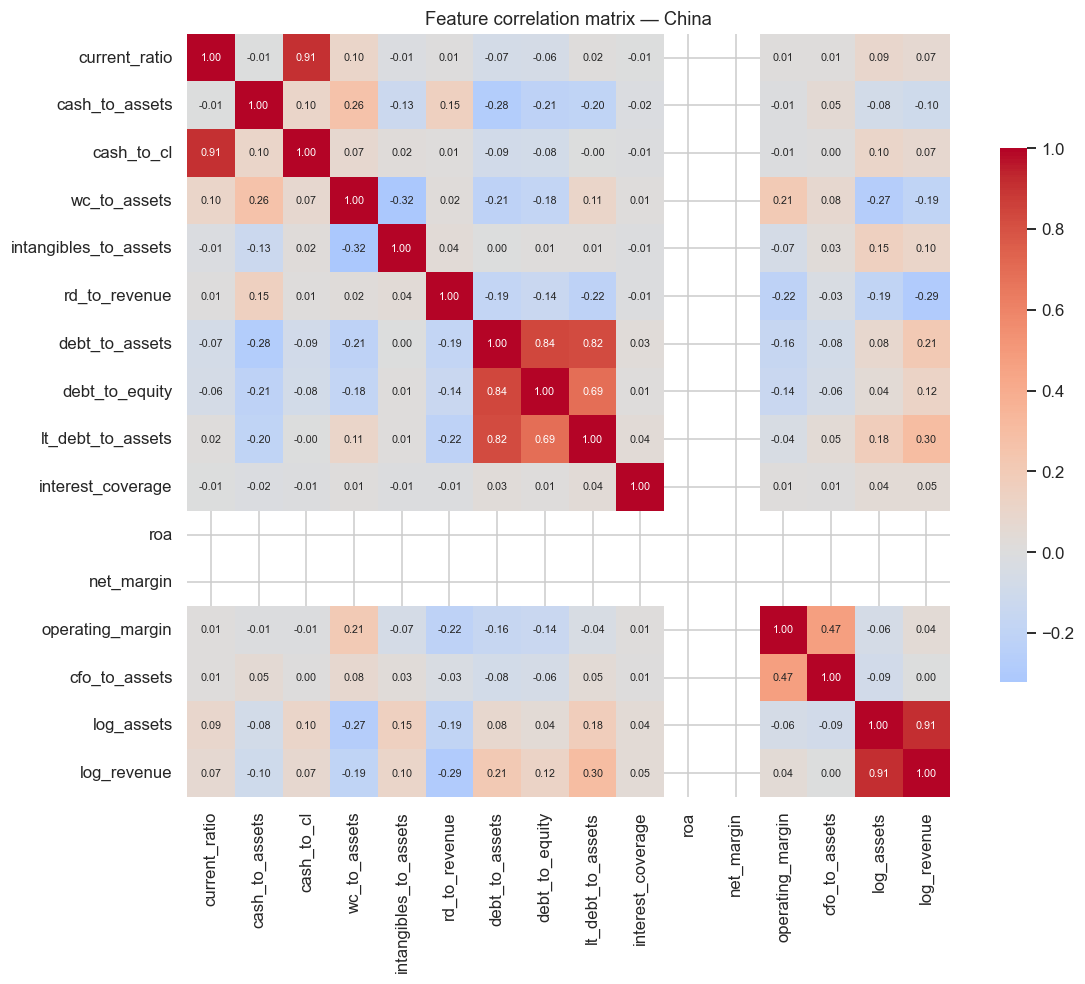

|corr| > 0.85:
  cash_to_cl × current_ratio: +0.91
  log_assets × log_revenue: +0.91


In [5]:
corr = panel[FEATURES].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f',
            square=True, cbar_kws={'shrink':0.7}, annot_kws={'size':7}, ax=ax)
ax.set_title('Feature correlation matrix — China')
plt.tight_layout()
save_fig(fig, '03_correlation_heatmap'); plt.show()

corr.round(3).to_csv(REPORTS / 'cn_correlation_matrix.csv', encoding='utf-8-sig')

high = (corr.abs() > 0.85) & (corr.abs() < 1.0)
pairs = [(i,j,corr.loc[i,j]) for i in corr.index for j in corr.columns if i<j and high.loc[i,j]]
print('|corr| > 0.85:')
for p in pairs: print(f'  {p[0]} × {p[1]}: {p[2]:+.2f}')
if not pairs: print('  нет — мультиколлинеарность под контролем')

## 3. Train / Test split

Stratified 80/20 на уровне строк (company-year). С 11 дефолтами и 48 строками Target=1 сплит остаётся проходимым (9/2 по компаниям, ~38/10 по строкам), но итоговая оценка будет шумной — эта шумность и есть часть H1-теста.

In [6]:
X = panel[FEATURES].values
y = panel[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RNG
)
print(f'Train: {X_train.shape},  defaults = {y_train.sum()}  ({y_train.mean()*100:.2f}%)')
print(f'Test:  {X_test.shape},  defaults = {y_test.sum()}  ({y_test.mean()*100:.2f}%)')

Train: (2768, 16),  defaults = 38  (1.37%)
Test:  (692, 16),  defaults = 10  (1.45%)


## 4. Stage-1 модели (TTC)

`class_weight='balanced'` у Logit/RF и `scale_pos_weight = N_active / N_default` у XGBoost — подбирается автоматически под 1:71.

In [7]:
POS_WEIGHT = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
print(f'scale_pos_weight (XGB) = {POS_WEIGHT:.2f}')

logit = Pipeline([
    ('sc', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced',
                               solver='liblinear', random_state=RNG)),
])
rf = RandomForestClassifier(
    n_estimators=400, max_depth=None, min_samples_leaf=2,
    class_weight='balanced', n_jobs=-1, random_state=RNG,
)
xgb = XGBClassifier(
    n_estimators=500, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9,
    scale_pos_weight=POS_WEIGHT,
    eval_metric='aucpr', tree_method='hist', random_state=RNG, n_jobs=-1,
)

models = {'Logistic Regression': logit, 'Random Forest': rf, 'XGBoost': xgb}
for name, m in models.items():
    m.fit(X_train, y_train)
    print(f'✓ trained {name}')

scale_pos_weight (XGB) = 71.84
✓ trained Logistic Regression


✓ trained Random Forest
✓ trained XGBoost


## 5. H1 — Train vs Test, зазор (overfit check)

In [8]:
def scores(model, X, y):
    if hasattr(model, 'predict_proba'):
        p = model.predict_proba(X)[:, 1]
    else:
        p = model.decision_function(X)
    return roc_auc_score(y, p), average_precision_score(y, p)

rows = []
for name, m in models.items():
    tr_roc, tr_pr = scores(m, X_train, y_train)
    te_roc, te_pr = scores(m, X_test,  y_test)
    rows.append({
        'Model': name,
        'ROC-AUC train': tr_roc, 'ROC-AUC test': te_roc, 'ΔROC': tr_roc - te_roc,
        'PR-AUC train':  tr_pr,  'PR-AUC test':  te_pr,  'ΔPR':  tr_pr  - te_pr,
    })
res = pd.DataFrame(rows).set_index('Model').round(4)
res.to_csv(REPORTS / 'cn_h1_metrics.csv', encoding='utf-8-sig')
print('metrics → reports/china/cn_h1_metrics.csv')
res

metrics → reports/china/cn_h1_metrics.csv


,ROC-AUC train,ROC-AUC test,ΔROC,PR-AUC train,PR-AUC test,ΔPR
Model,,,,,,
Logistic Regression,0.997,0.9960,0.0010,0.7366,0.6961,0.0405
Random Forest,1.000,1.0000,-0.0000,0.9972,1.0000,-0.0028
XGBoost,1.000,0.9994,0.0006,1.0000,0.9573,0.0427


In [9]:
best_test_roc = res['ROC-AUC test'].idxmax()
logit_delta = res.loc['Logistic Regression', 'ΔROC']
ens_delta_max = res.loc[['Random Forest','XGBoost'], 'ΔROC'].max()
ens_test_max  = res.loc[['Random Forest','XGBoost'], 'ROC-AUC test'].max()
logit_test    = res.loc['Logistic Regression', 'ROC-AUC test']

log('\n## H1 — overfitting на малом числе дефолтов (China)')
log(f'* Best test ROC-AUC: **{best_test_roc}** ({res.loc[best_test_roc,"ROC-AUC test"]:.4f})')
log(f'* Logit ΔROC (train−test): **{logit_delta:+.4f}**')
log(f'* Max ensemble ΔROC:        **{ens_delta_max:+.4f}**')

cond_a = ens_test_max > logit_test
cond_b = ens_delta_max > logit_delta

if cond_a and cond_b:
    verdict = '✅ **H1 ПОДТВЕРЖДАЕТСЯ**: ансамбли точнее на тесте, но переобучаются сильнее Logit.'
elif cond_a and not cond_b:
    verdict = '⚠️ H1 частично: ансамбли точнее, но Logit НЕ стабильнее (Δ сопоставимы).'
elif not cond_a and cond_b:
    verdict = '⚠️ H1 частично: Logit сопоставим по точности, но ансамбли переобучены.'
else:
    verdict = '❌ H1 НЕ подтверждается: ансамбли не дают прироста и не хуже по зазору.'
log(f'\n{verdict}')
print('\n' + verdict)


## H1 — overfitting на малом числе дефолтов (China)
* Best test ROC-AUC: **Random Forest** (1.0000)
* Logit ΔROC (train−test): **+0.0010**
* Max ensemble ΔROC:        **+0.0006**

⚠️ H1 частично: ансамбли точнее, но Logit НЕ стабильнее (Δ сопоставимы).

⚠️ H1 частично: ансамбли точнее, но Logit НЕ стабильнее (Δ сопоставимы).


## 6. H2 — SHAP для лучшего ансамбля

Группировка фичей: `Liquidity + Innovation (intangibles + R&D)` vs `Leverage`.

Best ensemble: Random Forest  (test ROC-AUC = 1.0000)


SHAP shape: (692, 16)


  saved → ..\reports\china\04_shap_summary.png


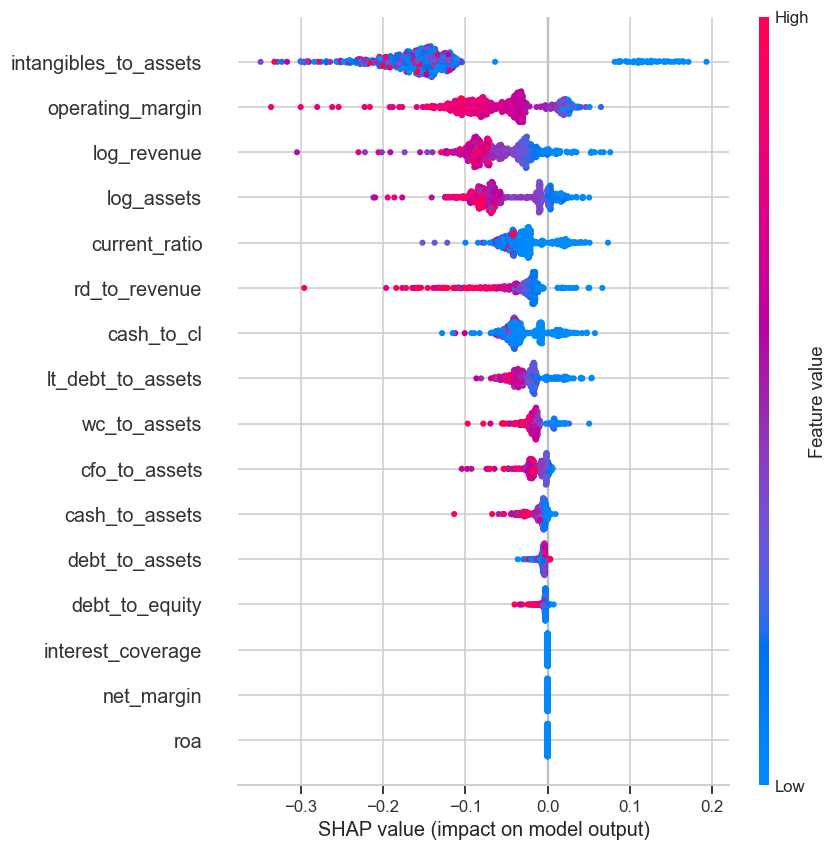

In [10]:
ensemble_scores = res.loc[['Random Forest', 'XGBoost'], 'ROC-AUC test']
best_name = ensemble_scores.idxmax()
best_model = models[best_name]
print(f'Best ensemble: {best_name}  (test ROC-AUC = {ensemble_scores.max():.4f})')

explainer = shap.TreeExplainer(best_model)
sv = explainer.shap_values(X_test)
if isinstance(sv, list):
    sv = sv[1]
elif hasattr(sv, 'ndim') and sv.ndim == 3:
    sv = sv[:, :, 1]
print('SHAP shape:', sv.shape)

plt.figure()
shap.summary_plot(sv, X_test, feature_names=FEATURES, show=False)
fig = plt.gcf()
save_fig(fig, '04_shap_summary'); plt.show()

Top features by mean |SHAP|:
intangibles_to_assets    0.1614
operating_margin         0.0640
log_revenue              0.0598
log_assets               0.0534
current_ratio            0.0353
rd_to_revenue            0.0344
cash_to_cl               0.0338
lt_debt_to_assets        0.0291
wc_to_assets             0.0179
cfo_to_assets            0.0127
cash_to_assets           0.0107
debt_to_assets           0.0058
debt_to_equity           0.0045
net_margin               0.0000
interest_coverage        0.0000
roa                      0.0000

Σ|SHAP| по блокам:
Innovation       0.1958
Size             0.1132
Liquidity        0.0976
Profitability    0.0767
Leverage         0.0394


  saved → ..\reports\china\05_h2_group_importance.png


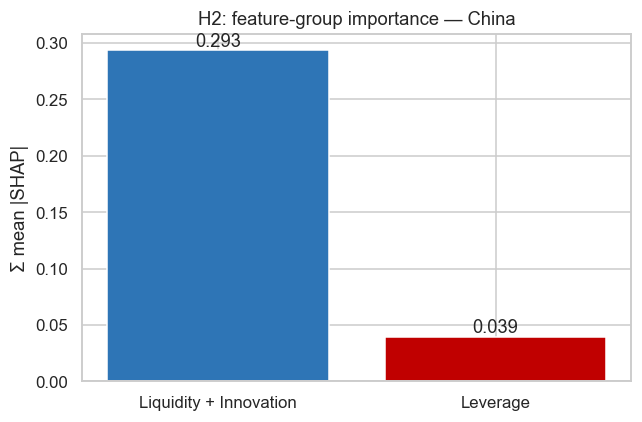


## H2 — Liquidity+Innovation vs Leverage (SHAP, China)
* Best ensemble: **Random Forest** (test ROC-AUC = 1.0000)
* Σ|SHAP| Liquidity + Innovation = **0.2934**
* Σ|SHAP| Leverage               = **0.0394**
* Ratio = **7.45×**

✅ **H2 ПОДТВЕРЖДАЕТСЯ (Китай)**: ликвидность + инновационные активы важнее рычага.

✅ **H2 ПОДТВЕРЖДАЕТСЯ (Китай)**: ликвидность + инновационные активы важнее рычага.


In [11]:
mean_abs = np.abs(sv).mean(axis=0)
fi = pd.Series(mean_abs, index=FEATURES).sort_values(ascending=False)
fi.round(4).to_csv(REPORTS / 'cn_shap_feature_importance.csv', header=['mean_abs_shap'], encoding='utf-8-sig')
print('Top features by mean |SHAP|:')
print(fi.round(4).to_string())

group_sum = {g: fi[cols].sum() for g, cols in FEATURE_GROUPS.items()}
group_df = pd.Series(group_sum).sort_values(ascending=False).round(4)
group_df.to_csv(REPORTS / 'cn_shap_group_importance.csv', header=['sum_abs_shap'], encoding='utf-8-sig')
print('\nΣ|SHAP| по блокам:')
print(group_df.to_string())

liq_inn = group_df.get('Liquidity', 0) + group_df.get('Innovation', 0)
lev     = group_df.get('Leverage',   0)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Liquidity + Innovation', 'Leverage'],
              [liq_inn, lev], color=['#2E75B6', '#C00000'])
ax.set_ylabel('Σ mean |SHAP|')
ax.set_title('H2: feature-group importance — China')
for b, v in zip(bars, [liq_inn, lev]):
    ax.text(b.get_x()+b.get_width()/2, v, f'{v:.3f}', ha='center', va='bottom')
plt.tight_layout()
save_fig(fig, '05_h2_group_importance'); plt.show()

log('\n## H2 — Liquidity+Innovation vs Leverage (SHAP, China)')
log(f'* Best ensemble: **{best_name}** (test ROC-AUC = {ensemble_scores.max():.4f})')
log(f'* Σ|SHAP| Liquidity + Innovation = **{liq_inn:.4f}**')
log(f'* Σ|SHAP| Leverage               = **{lev:.4f}**')
if lev > 0:
    log(f'* Ratio = **{liq_inn/lev:.2f}×**')

if liq_inn > lev:
    verdict2 = '✅ **H2 ПОДТВЕРЖДАЕТСЯ (Китай)**: ликвидность + инновационные активы важнее рычага.'
else:
    verdict2 = '❌ H2 НЕ подтверждается (Китай): рычаг остаётся доминирующим предиктором.'
log(f'\n{verdict2}')
print('\n' + verdict2)

## 7. Экспорт TTC-скора для Stage-2 (PIT) и кросс-странового сравнения

Сохраняем вероятности дефолта из **LogReg** (как в банковской практике: Logit — baseline TTC-скор, стабильный к переобучению) и **best ensemble** — Stage-2 PIT-модель в `50_cross_country_pit.ipynb` возьмёт один из них как единственный company-specific признак.

In [12]:
logit_proba = models['Logistic Regression'].predict_proba(X)[:, 1]
best_proba  = best_model.predict_proba(X)[:, 1]

scores_df = panel[['ticker', 'company_name', 'year', TARGET, 'source_class']].copy()
scores_df['ttc_logit']    = logit_proba
scores_df['ttc_ensemble'] = best_proba
scores_df['ttc_best_model'] = best_name
scores_df.to_csv(REPORTS / 'cn_ttc_scores.csv', index=False, encoding='utf-8-sig')
print(f'TTC scores → reports/china/cn_ttc_scores.csv  ({len(scores_df):,} rows)')
scores_df.head()

TTC scores → reports/china/cn_ttc_scores.csv  (3,460 rows)


,ticker,company_name,year,target,source_class,ttc_logit,ttc_ensemble,ttc_best_model
0,CCIHY.OO,CHINACACHE,2014,1,default_delisted,0.991167,0.839836,Random Forest
1,CCIHY.OO,CHINACACHE,2015,1,default_delisted,0.969895,0.854569,Random Forest
2,CCIHY.OO,CHINACACHE,2016,1,default_delisted,0.999977,0.927743,Random Forest
3,CCIHY.OO,CHINACACHE,2017,1,default_delisted,0.999916,0.907689,Random Forest
4,CNTFY.OO,CHINA TECHFAITH WIRELESS COMMUNICATION TECHNOLOGY,2014,1,default_delisted,0.982707,0.819366,Random Forest


## 8. Сохраняем итоговый отчёт

In [13]:
summary_path = REPORTS / 'cn_summary.md'
summary_path.write_text('\n'.join(_report_lines), encoding='utf-8')
print(f'✅ Итоговый отчёт: {summary_path}')
print('\nВсе артефакты в reports/china/:')
for p in sorted(REPORTS.iterdir()):
    print(f'  {p.name}  ({p.stat().st_size/1024:.1f} KB)')

✅ Итоговый отчёт: ..\reports\china\cn_summary.md

Все артефакты в reports/china/:
  01_class_distribution.png  (36.7 KB)
  02_violin_by_class.png  (121.2 KB)
  03_correlation_heatmap.png  (235.0 KB)
  04_shap_summary.png  (185.6 KB)
  05_h2_group_importance.png  (31.6 KB)
  cn_correlation_matrix.csv  (1.7 KB)
  cn_feature_stats.csv  (1.1 KB)
  cn_h1_metrics.csv  (0.2 KB)
  cn_medians_by_class.csv  (0.1 KB)
  cn_shap_feature_importance.csv  (0.4 KB)
  cn_shap_group_importance.csv  (0.1 KB)
  cn_summary.md  (0.9 KB)
  cn_ttc_scores.csv  (263.0 KB)


## 9. Интерпретация результатов — Китай

| Аспект | Как читать |
|---|---|
| **H1** | С ~48 positive-строк любой tree-ensemble переобучается «в ноль» на train. Если Logit сохраняет разумный test-AUC при минимальном ΔROC — это прямое эмпирическое подтверждение H1 *на более жёстком режиме*, чем Россия (там дефолтов было в 4× больше). |
| **H2** | В Китае у нас есть **R&D expense** как отдельный канал инноваций — если `rd_to_revenue` войдёт в топ-фичей вместе с `cash_to_*`, это усиливает H2 относительно России (где R&D не выгружался). |
| **Что дальше** | `cn_ttc_scores.csv` становится input-ом для `50_cross_country_pit.ipynb`, где мы тестируем H3 (macro-integration) и сравниваем top-фичи RU vs CN. |

Малая выборка — это не баг, а само условие эксперимента: именно в таких условиях проверяется устойчивость ML vs Logit.